# Diagnosis of Breast Cancer using Classification 

## Project Overview

Based on the `wdbc.csv` details, let's understand the dataset: 

1) id - Patient ID number
2) diagnosis - Target (M = Malignant, B = Benign)
3) radius_mean - Mean radius
4) texture_mean - Mean texture
5) perimeter_mean - Mean perimeter
6) area_mean - Mean area
7) smoothness_mean - Mean smoothness
8) compactness_mean - Mean compactness
9) concavity_mean - Mean concavity
10)	concave_points_mean - Mean concave points
11)	symmetry_mean - Mean symmetry
12)	fractal_dimension_mean - Mean fractal dimension
13)	radius_se - Standard error of radius
14)	texture_se - Standard error of texture
15)	perimeter_se - Standard error of perimeter
16)	area_se - Standard error of area
17)	smoothness_se - Standard error of smoothness
18)	compactness_se - Standard error of compactness
19) concavity_se - Standard error of concavity
20) concave_points_se - Standard error of concave points
21) symmetry_se - Standard error of symmetry
22) fractal_dimension_se - Standard error of fractal dimension
23) radius_worst - Worst (largest) radius
24) texture_worst - Worst texture
25) perimeter_worst - Worst perimeter
26) area_worst - Worst area
27) smoothness_worst - Worst smoothness
28) compactness_worst - Worst compactness
29) concavity_worst - Worst concavity
30) concave_points_worst - Worst concave points
31) symmetry_worst - Worst symmetry
32)	fractal_dimension_worst	Worst fractal dimension

Based on the details, we know that `diagnosis` is our target variable. Other varibales is used to predict it. By evaluating the target variable, we know that the values is continous number, thus this problem is referring to Regression.

<br><br><br><br><br>

## Dataset Understanding

In [1]:
import pandas as pd
data = pd.read_csv('wdbc.csv')

print("First 5 rows of dataset:")
print(data.head())

print("\n")

print("Dataset Shape:")
print(data.shape)

print("\n")

print("Dataset Information:")
data.info()

print("\n")

print("Dataset Description:")
print(data.describe())

First 5 rows of dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  

<Axes: xlabel='diagnosis'>

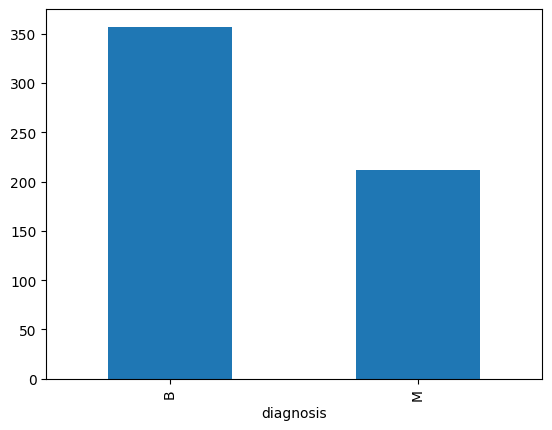

In [2]:
data['diagnosis'].value_counts().plot(kind = 'bar')

<br><br><br><br><br>

## Exploratory Data Analysis (EDA)
### Univariative Analysis

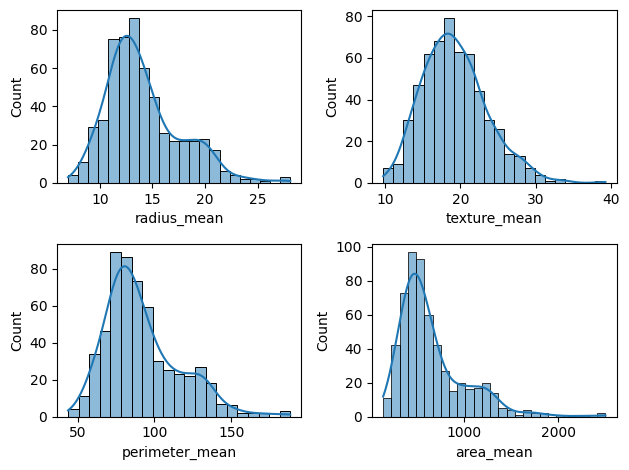

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns

def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(
        data=data,
        x=var,
        kde=True
    )

plotting("radius_mean", 1)
plotting("texture_mean", 2)
plotting("perimeter_mean", 3)
plotting("area_mean", 4)

plt.tight_layout()
plt.show()

### Bivariative Analysis
#### Histogram

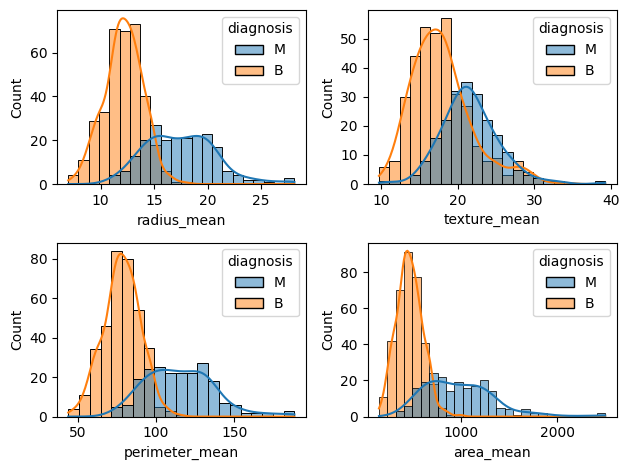

In [4]:
def plotting(var, num):
    plt.subplot(2, 2, num)

    sns.histplot(
        data=data,
        x=var,
        hue="diagnosis",
        kde=True
    )

plotting("radius_mean", 1)
plotting("texture_mean", 2)
plotting("perimeter_mean", 3)
plotting("area_mean", 4)

plt.tight_layout()
plt.show()

#### Boxplot

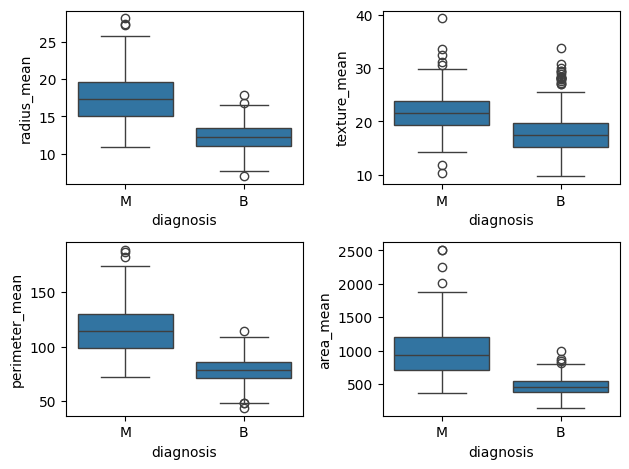

In [5]:
def plotting(var, num):
    plt.subplot(2, 2, num)

    sns.boxplot(
        data=data,
        x="diagnosis",
        y=var
    )

plotting("radius_mean", 1)
plotting("texture_mean", 2)
plotting("perimeter_mean", 3)
plotting("area_mean", 4)

plt.tight_layout()
plt.show()

### Multiivariative Analysis
#### Correlation Matrix

In [6]:
correlation_matrix = data.corr(numeric_only=True)
print("Correlation Matrix: ")
print(correlation_matrix)

Correlation Matrix: 
                               id  radius_mean  texture_mean  perimeter_mean  \
id                       1.000000     0.074626      0.099770        0.073159   
radius_mean              0.074626     1.000000      0.323782        0.997855   
texture_mean             0.099770     0.323782      1.000000        0.329533   
perimeter_mean           0.073159     0.997855      0.329533        1.000000   
area_mean                0.096893     0.987357      0.321086        0.986507   
smoothness_mean         -0.012968     0.170581     -0.023389        0.207278   
compactness_mean         0.000096     0.506124      0.236702        0.556936   
concavity_mean           0.050080     0.676764      0.302418        0.716136   
concave_points_mean      0.044158     0.822529      0.293464        0.850977   
symmetry_mean           -0.022114     0.147741      0.071401        0.183027   
fractal_dimension_mean  -0.052511    -0.311631     -0.076437       -0.261477   
radius_se          

#### Heatmap

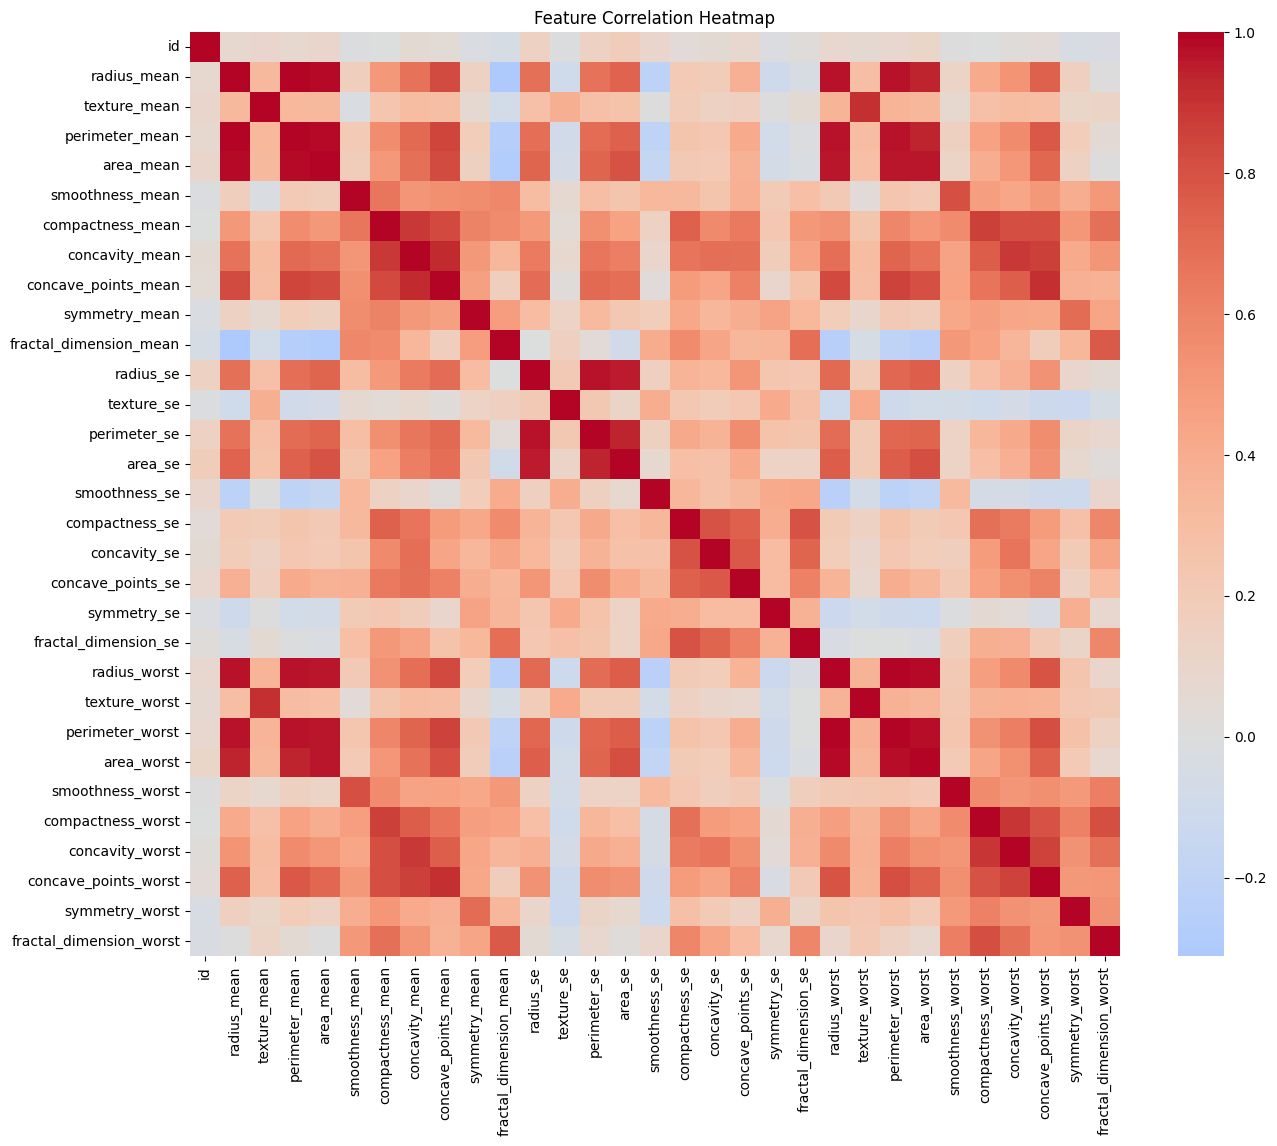

In [7]:
plt.figure(figsize=(15,12))

sns.heatmap(
    data.drop("diagnosis", axis=1).corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

#### Pairplot

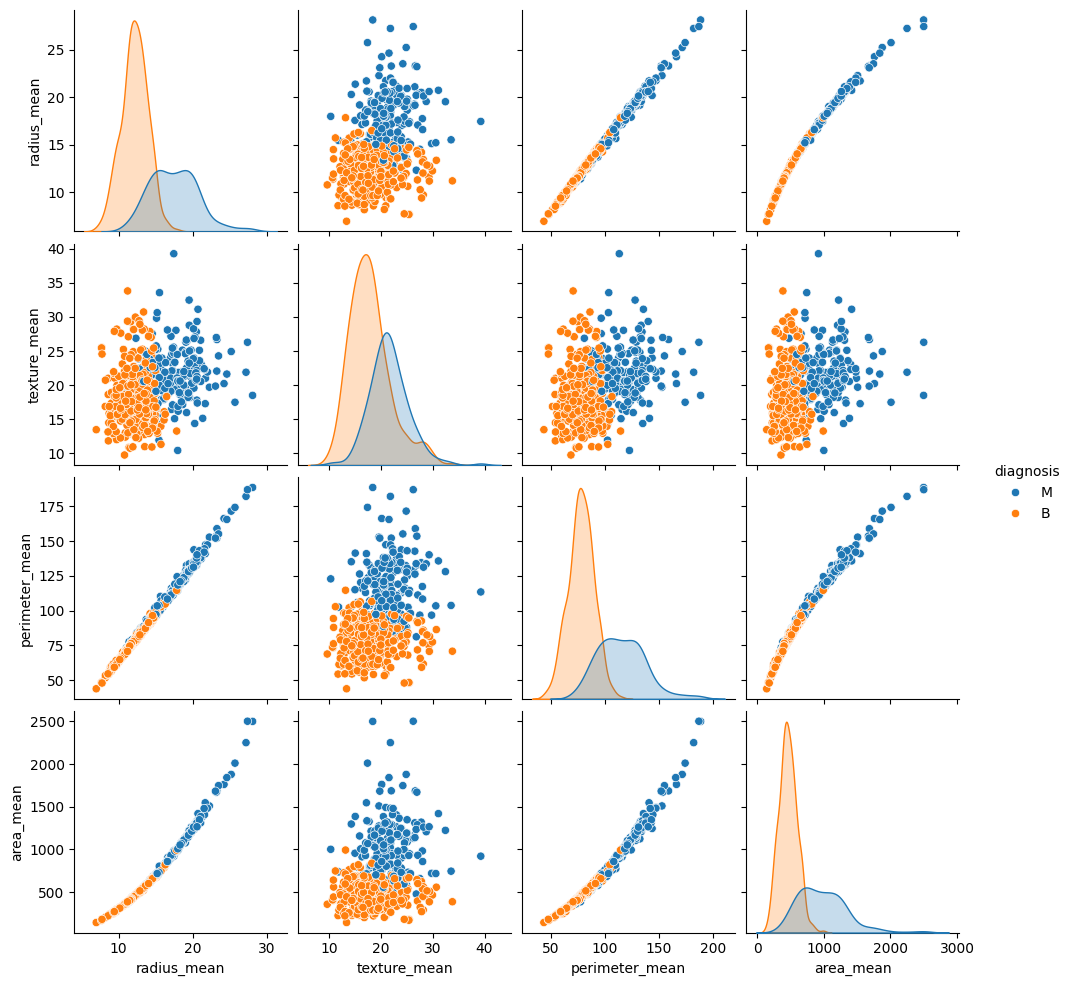

In [8]:
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "diagnosis"
]

sns.pairplot(
    data[selected_features],
    hue="diagnosis"
)

plt.show()

<br><br><br><br><br>

## Data Cleaning 

In [9]:
duplicate_mask = data.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# data = data.drop_duplicates()
# print("Shape after dropping duplicates:", data.shape)

Number of duplicate rows: 0


In [10]:
# Remove meaningless columns
data = data.drop(
    "id",
    axis=1
)

<br><br><br><br><br>

## Data Preparation 

In [11]:
# 1. Train-Test Split
from sklearn.model_selection import train_test_split

# Separate features and target
X = data.drop(
    "diagnosis",
    axis=1
)

# Because the target value is not numeric, therefore need to change
y = data["diagnosis"].map(
    {
        "B": 0,
        "M": 1
    }
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set")
print(X_train.shape)
print("\n")

print("Testing Set")
print(X_test.shape)
print("\n")

# 2. Identify Numerical and Categorical Features
numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)
print("\n")

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)
print("\n")

# 3. Identify Missing Values
print("Missing Values:")
print(data.isnull().sum())

Training Set
(455, 30)


Testing Set
(114, 30)


Numerical Features:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']


Categorical Features:
[]


Missing Values:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se            

<br><br><br><br><br>

## Data Preprocessing

In [12]:
# Numerical Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numerical Preprocessing Pipeline:")
print(numerical_pipeline)
print("\n")

# Categorical Preprocessing Pipeline
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical Preprocessing Pipeline:")
print(categorical_pipeline)
print("\n")

# Combine Pipelines
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Combined Preprocessing Pipeline:")
print(preprocessor)

Numerical Preprocessing Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


Categorical Preprocessing Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


Combined Preprocessing Pipeline:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave_points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                     

<br><br><br><br><br>

## Build Baseline Model 

In [13]:
# Build Baseline Model
from sklearn.linear_model import LogisticRegression

# Complete Machine Learning Pipeline
from sklearn.pipeline import Pipeline
model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

print("Complete Machine Learning Pipeline:")
print(model_pipeline)
print("\n")

# Train the Pipeline
model_pipeline.fit(
    X_train,
    y_train
)

Complete Machine Learning Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['radius_mean',
                                                   'texture_mean',
                                                   'perimeter_mean',
                                                   'area_mean',
                                                   'smoothness_mean',
                                                   'compactness_mean',
                                                   'concavity_mean',
                                                   'c

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave_points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

<br><br><br><br><br>

## Model Evaluation (Baseline Model)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Training Set Evaluation
train_baseline_pred = model_pipeline.predict(
    X_train
)

train_baseline_prob = model_pipeline.predict_proba(
    X_train
)[:,1]

train_accuracy = accuracy_score(
    y_train,
    train_baseline_pred
)

train_precision = precision_score(
    y_train,
    train_baseline_pred
)

train_recall = recall_score(
    y_train,
    train_baseline_pred
)

train_f1 = f1_score(
    y_train,
    train_baseline_pred
)

train_auc = roc_auc_score(
    y_train,
    train_baseline_prob
)

print("TRAIN BASELINE METRICS:")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1-score : {train_f1:.4f}")
print(f"ROC-AUC  : {train_auc:.4f}")

print("\n")

# Testing Set Evaluation
test_baseline_pred = model_pipeline.predict(
    X_test
)

test_baseline_prob = model_pipeline.predict_proba(
    X_test
)[:,1]

test_accuracy = accuracy_score(
    y_test,
    test_baseline_pred
)

test_precision = precision_score(
    y_test,
    test_baseline_pred
)

test_recall = recall_score(
    y_test,
    test_baseline_pred
)

test_f1 = f1_score(
    y_test,
    test_baseline_pred
)

test_auc = roc_auc_score(
    y_test,
    test_baseline_prob
)

print("TEST BASELINE METRICS:")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

TRAIN BASELINE METRICS:
Accuracy : 0.9868
Precision: 1.0000
Recall   : 0.9647
F1-score : 0.9820
ROC-AUC  : 0.9976


TEST BASELINE METRICS:
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1-score : 0.9512
ROC-AUC  : 0.9960


In [15]:
# Classification Report 
print(
    classification_report(
        y_test,
        test_baseline_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



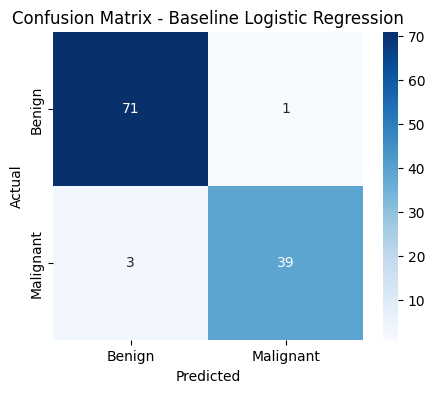

In [16]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    test_baseline_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix - Baseline Logistic Regression"
)

plt.show()

<br><br><br><br><br>

## Model Interpretation 

In [17]:
import pandas as pd

# Extract trained Logistic Regression model
log_model = model_pipeline.named_steps["model"]

# Extract coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coefficients

,Feature,Coefficient
0,radius_mean,0.361150
1,texture_mean,0.482219
2,perimeter_mean,0.353160
3,area_mean,0.439950
4,smoothness_mean,0.350622
5,compactness_mean,-0.439546
6,concavity_mean,0.782298
7,concave_points_mean,0.952813
8,symmetry_mean,-0.163991
9,fractal_dimension_mean,-0.080865


In [18]:
import numpy as np

coefficients["Odds_Ratio"] = np.exp(
    coefficients["Coefficient"]
)

coefficients.sort_values(
    by="Odds_Ratio",
    ascending=False
)

,Feature,Coefficient,Odds_Ratio
21,texture_worst,1.434093,4.195838
10,radius_se,1.233325,3.432625
28,symmetry_worst,1.061264,2.890021
7,concave_points_mean,0.952813,2.592993
26,concavity_worst,0.911406,2.487817
13,area_se,0.909029,2.481912
23,area_worst,0.900477,2.460776
20,radius_worst,0.896968,2.452156
6,concavity_mean,0.782298,2.186492
12,perimeter_se,0.748295,2.113393


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
23,area_worst,0.151412
27,concave_points_worst,0.126497
20,radius_worst,0.093475
22,perimeter_worst,0.083642
7,concave_points_mean,0.081082
2,perimeter_mean,0.077126
0,radius_mean,0.061990
6,concavity_mean,0.050818
3,area_mean,0.045916
26,concavity_worst,0.030022


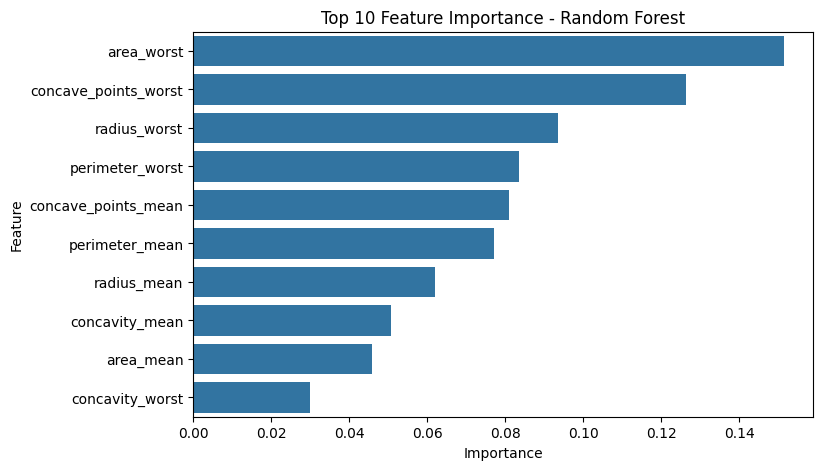

In [20]:
# Visualization 
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_sorted,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importance - Random Forest"
)

plt.show()

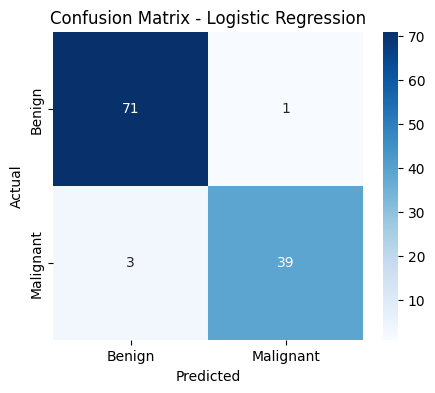

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediction using pipeline
y_pred = model_pipeline.predict(
    X_test
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.show()

SHAP values shape: (114, 30, 2)


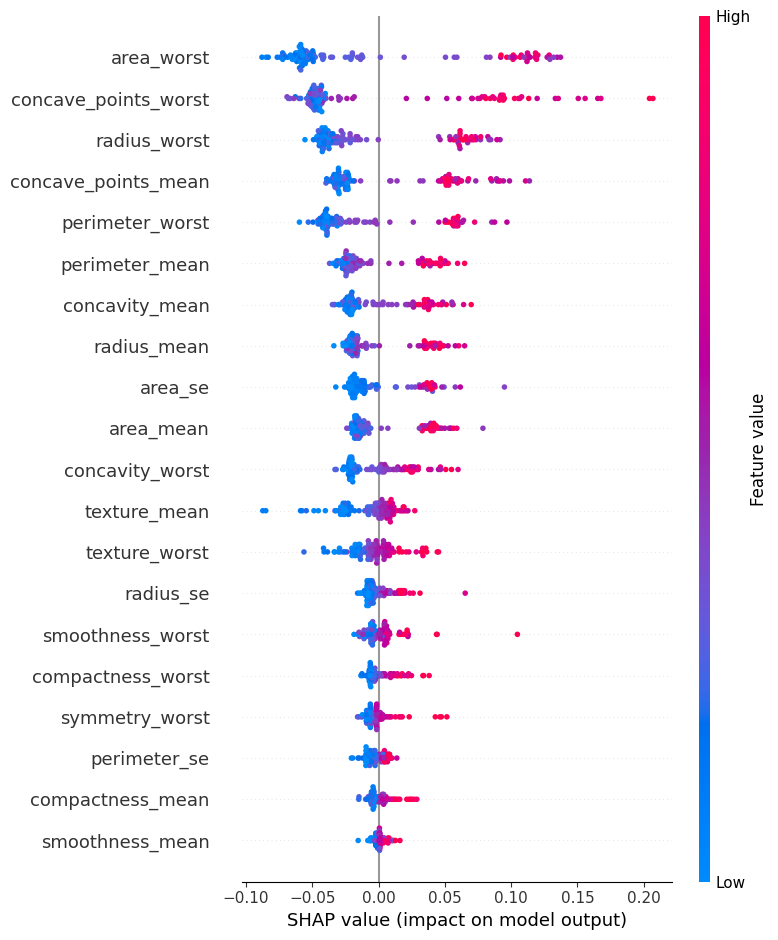

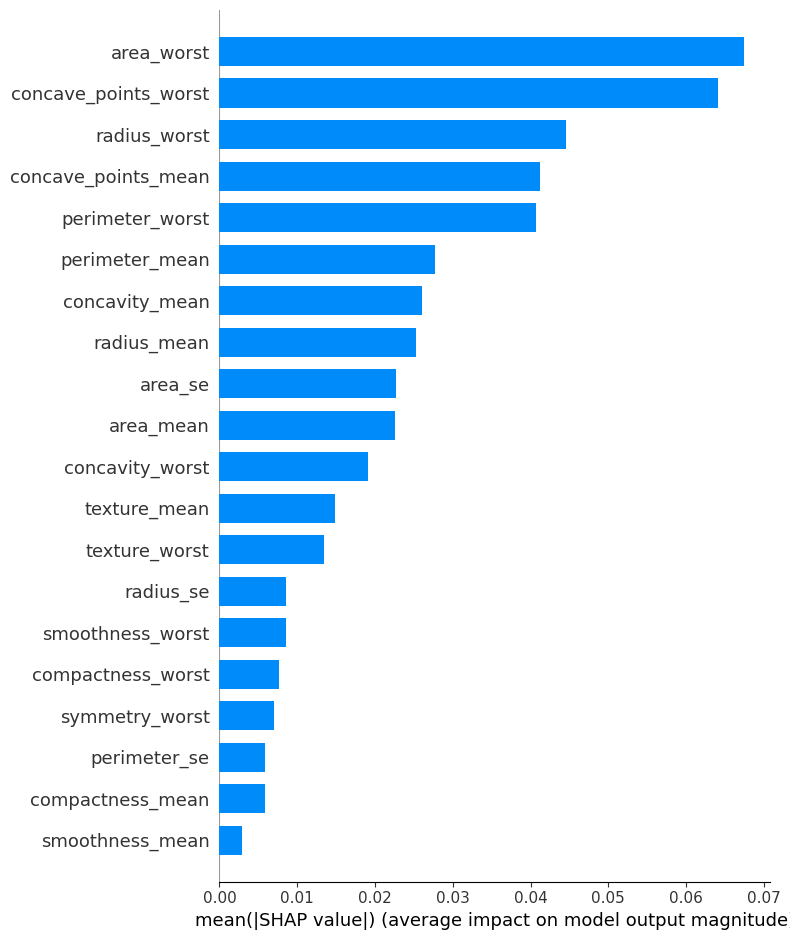

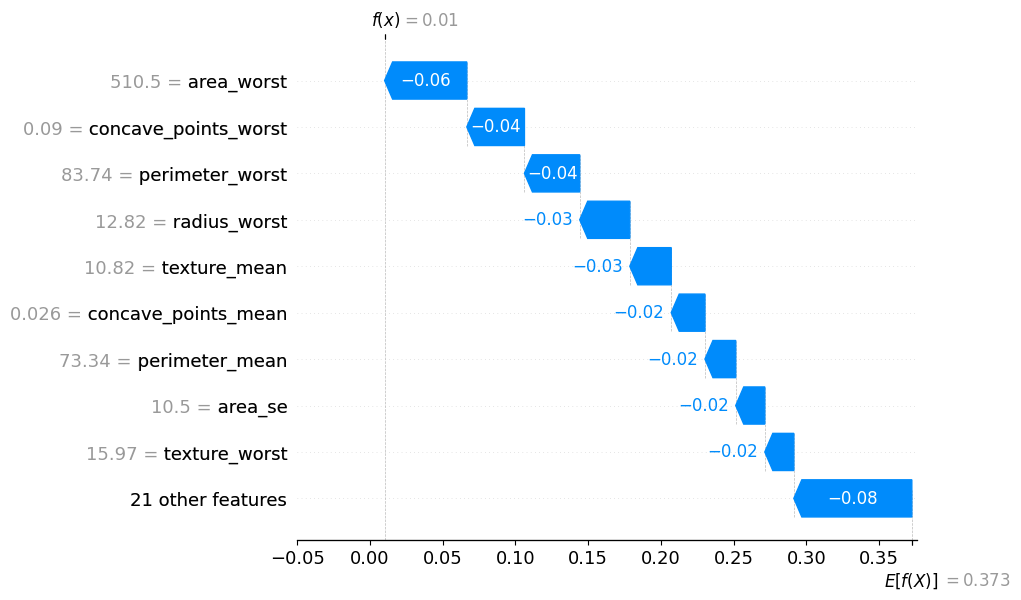

In [22]:
# SHAP Model Explainability
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(
    rf
)

# Generate SHAP values
shap_values = explainer(
    X_test
)

# Display SHAP shape
print(
    "SHAP values shape:",
    shap_values.values.shape
)


# Global Feature Importance
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_test
)


# Feature Importance Ranking
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_test,
    plot_type="bar"
)


# Individual Prediction Explanation
sample_index = 0

shap.plots.waterfall(
    shap_values[sample_index, :, 1]
)

<br><br><br><br><br>

## Model Selection 

In [23]:
# Models to try 
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier
)
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000
    ),
    "RidgeClassifier": RidgeClassifier(),
    "RandomForest": RandomForestClassifier(
        random_state=42
    ),
    "HistGB": HistGradientBoostingClassifier(
        random_state=42
    ),
    "SVM": CalibratedClassifierCV(
        SVC(
            random_state=42
        ),
        ensemble=False
    )
}

In [24]:
# Cross Validation Setup
from sklearn.model_selection import StratifiedKFold

k = 5
cv = StratifiedKFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

In [25]:
# Evaluation Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [26]:
# Cross Validation Model Comparison 
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            (
                "preprocess",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    rows.append({
        "model": name,
        "cv_accuracy":
            scores["test_accuracy"].mean(),
        "cv_precision":
            scores["test_precision"].mean(),
        "cv_recall":
            scores["test_recall"].mean(),
        "cv_f1":
            scores["test_f1"].mean(),
        "cv_roc_auc":
            scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(rows)

# Sort by F1-score
cv_results = cv_results.sort_values(
    by="cv_f1",
    ascending=False
)

print("Cross Validation Model Comparison:")
print(cv_results)

Cross Validation Model Comparison:
                model  cv_accuracy  cv_precision  cv_recall     cv_f1  \
4                 SVM     0.975824      0.977292   0.958824  0.967043   
0  LogisticRegression     0.973626      0.977143   0.952941  0.964048   
2        RandomForest     0.964835      0.964095   0.941176  0.951945   
1     RidgeClassifier     0.958242      0.993548   0.894118  0.940342   
3              HistGB     0.956044      0.957519   0.923529  0.939919   

   cv_roc_auc  
4    0.994943  
0    0.995769  
2    0.988906  
1    0.995459  
3    0.993086  


In [27]:
# Select the best model 
best_row = cv_results.iloc[0]
best_model_name = best_row["model"]
best_f1 = best_row["cv_f1"]

print("Best model based on Cross Validation F1-score:")
print("Model:", best_model_name)
print("Cross Validation F1-score:",best_f1)

Best model based on Cross Validation F1-score:
Model: SVM
Cross Validation F1-score: 0.9670432721583617


<br><br><br><br><br>

## Hyperparameter Tuning 

In [28]:
# Create Logistic Regression Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_pipe = Pipeline(
    steps=[
        (
            "preprocess",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)
print(log_pipe)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['radius_mean',
                                                   'texture_mean',
                                                   'perimeter_mean',
                                                   'area_mean',
                                                   'smoothness_mean',
                                                   'compactness_mean',
                                                   'concavity_mean',
                                                   'concave_points_mean',
                 

In [29]:
param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "model__l1_ratio": [
        0,
        0.25,
        0.5,
        0.75,
        1
    ],
    "model__solver": [
        "saga"
    ]
}

In [30]:
# Grid Search with Cross Validation
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [31]:
# Train grid search 
grid.fit(
    X_train,
    y_train
)

print("Tuned Logistic Regression Result:")
print("Best CV F1-score:",grid.best_score_)
print("Best Parameters:",grid.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Tuned Logistic Regression Result:
Best CV F1-score: 0.9668613888243044
Best Parameters: {'model__C': 1, 'model__l1_ratio': 0.25, 'model__solver': 'saga'}


In [32]:
best_model = grid.best_estimator_

<br><br><br><br><br>

## Retrain with best parameters 

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create final tuned Logistic Regression pipeline
log_best = Pipeline(
    steps=[
        (
            "preprocess",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                C=1,
                l1_ratio=0.5,
                solver="saga",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train best model on entire training data
log_best.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave_points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

<br><br><br><br><br>

## Final Evaluation 

In [34]:
# Model Evaluation (Training set)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Training Set Evaluation
train_final_pred = log_best.predict(
    X_train
)

train_final_prob = log_best.predict_proba(
    X_train
)[:,1]

train_final_accuracy = accuracy_score(
    y_train,
    train_final_pred
)

train_final_precision = precision_score(
    y_train,
    train_final_pred
)

train_final_recall = recall_score(
    y_train,
    train_final_pred
)

train_final_f1 = f1_score(
    y_train,
    train_final_pred
)

train_final_auc = roc_auc_score(
    y_train,
    train_final_prob
)

print("Final Model (Tuned Logistic Regression) Train Performance:")
print(f"Accuracy : {train_final_accuracy:.3f}")
print(f"Precision: {train_final_precision:.3f}")
print(f"Recall   : {train_final_recall:.3f}")
print(f"F1-score : {train_final_f1:.3f}")
print(f"ROC-AUC  : {train_final_auc:.3f}")

Final Model (Tuned Logistic Regression) Train Performance:
Accuracy : 0.985
Precision: 0.994
Recall   : 0.965
F1-score : 0.979
ROC-AUC  : 0.998


In [35]:
# Model Evaluation (Testing set)
test_final_pred = log_best.predict(
    X_test
)

test_final_prob = log_best.predict_proba(
    X_test
)[:,1]

test_final_accuracy = accuracy_score(
    y_test,
    test_final_pred
)

test_final_precision = precision_score(
    y_test,
    test_final_pred
)

test_final_recall = recall_score(
    y_test,
    test_final_pred
)

test_final_f1 = f1_score(
    y_test,
    test_final_pred
)

test_final_auc = roc_auc_score(
    y_test,
    test_final_prob
)

print("Final Model (Tuned Logistic Regression) Test Performance:")
print(f"Accuracy : {test_final_accuracy:.3f}")
print(f"Precision: {test_final_precision:.3f}")
print(f"Recall   : {test_final_recall:.3f}")
print(f"F1-score : {test_final_f1:.3f}")
print(f"ROC-AUC  : {test_final_auc:.3f}")

Final Model (Tuned Logistic Regression) Test Performance:
Accuracy : 0.965
Precision: 0.975
Recall   : 0.929
F1-score : 0.951
ROC-AUC  : 0.997


In [36]:
# Classification Report 
print(
    classification_report(
        y_test,
        test_final_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



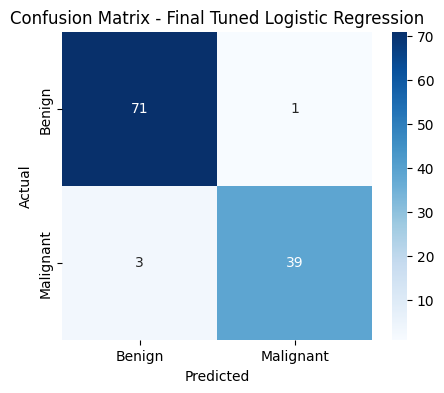

In [37]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_final_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)

plt.xlabel(
    "Predicted"
)
plt.ylabel(
    "Actual"
)
plt.title(
    "Confusion Matrix - Final Tuned Logistic Regression"
)

plt.show()

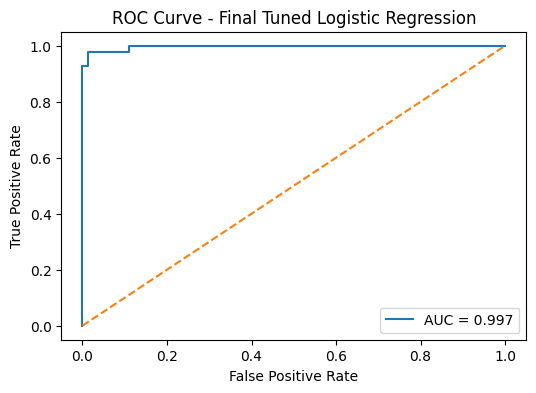

In [38]:
# ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_final_prob
)

roc_auc = auc(
    fpr,
    tpr
)
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Final Tuned Logistic Regression"
)

plt.legend()
plt.show()

<br><br><br><br><br>

## Building a Predictive System 

In [39]:
def predict_breast_cancer(
    model,
    radius_mean: float,
    texture_mean: float,
    perimeter_mean: float,
    area_mean: float,
    smoothness_mean: float,
    compactness_mean: float,
    concavity_mean: float,
    concave_points_mean: float,
    symmetry_mean: float,
    fractal_dimension_mean: float,
    radius_se: float,
    texture_se: float,
    perimeter_se: float,
    area_se: float,
    smoothness_se: float,
    compactness_se: float,
    concavity_se: float,
    concave_points_se: float,
    symmetry_se: float,
    fractal_dimension_se: float,
    radius_worst: float,
    texture_worst: float,
    perimeter_worst: float,
    area_worst: float,
    smoothness_worst: float,
    compactness_worst: float,
    concavity_worst: float,
    concave_points_worst: float,
    symmetry_worst: float,
    fractal_dimension_worst: float
):
    """
    Predict breast cancer diagnosis.

    Output:
    0 = Benign
    1 = Malignant

    The pipeline automatically performs:
    - missing value imputation
    - feature scaling
    - prediction
    """

    new_row = pd.DataFrame([{

        "radius_mean": radius_mean,
        "texture_mean": texture_mean,
        "perimeter_mean": perimeter_mean,
        "area_mean": area_mean,
        "smoothness_mean": smoothness_mean,
        "compactness_mean": compactness_mean,
        "concavity_mean": concavity_mean,
        "concave_points_mean": concave_points_mean,
        "symmetry_mean": symmetry_mean,
        "fractal_dimension_mean": fractal_dimension_mean,

        "radius_se": radius_se,
        "texture_se": texture_se,
        "perimeter_se": perimeter_se,
        "area_se": area_se,
        "smoothness_se": smoothness_se,
        "compactness_se": compactness_se,
        "concavity_se": concavity_se,
        "concave_points_se": concave_points_se,
        "symmetry_se": symmetry_se,
        "fractal_dimension_se": fractal_dimension_se,

        "radius_worst": radius_worst,
        "texture_worst": texture_worst,
        "perimeter_worst": perimeter_worst,
        "area_worst": area_worst,
        "smoothness_worst": smoothness_worst,
        "compactness_worst": compactness_worst,
        "concavity_worst": concavity_worst,
        "concave_points_worst": concave_points_worst,
        "symmetry_worst": symmetry_worst,
        "fractal_dimension_worst": fractal_dimension_worst

    }])

    prediction = model.predict(
        new_row
    )[0]

    probability = model.predict_proba(
        new_row
    )[0][1]

    if prediction == 1:
        diagnosis = "Malignant"
    else:
        diagnosis = "Benign"

    return {
        "prediction": int(prediction),
        "diagnosis": diagnosis,
        "malignant_probability": round(
            probability,
            4
        )
    }

In [40]:
# Example 
example_result = predict_breast_cancer(
    model=log_best,

    radius_mean=17.99,
    texture_mean=10.38,
    perimeter_mean=122.8,
    area_mean=1001,

    smoothness_mean=0.1184,
    compactness_mean=0.2776,
    concavity_mean=0.3001,
    concave_points_mean=0.1471,
    symmetry_mean=0.2419,
    fractal_dimension_mean=0.07871,

    radius_se=1.095,
    texture_se=0.9053,
    perimeter_se=8.589,
    area_se=153.4,
    smoothness_se=0.006399,
    compactness_se=0.04904,
    concavity_se=0.05373,
    concave_points_se=0.01587,
    symmetry_se=0.03003,
    fractal_dimension_se=0.006193,

    radius_worst=25.38,
    texture_worst=17.33,
    perimeter_worst=184.6,
    area_worst=2019,

    smoothness_worst=0.1622,
    compactness_worst=0.6656,
    concavity_worst=0.7119,
    concave_points_worst=0.2654,
    symmetry_worst=0.4601,
    fractal_dimension_worst=0.1189
)

print(example_result)

{'prediction': 1, 'diagnosis': 'Malignant', 'malignant_probability': np.float64(1.0)}


<br><br><br><br><br>

## Model Deployment 

In [41]:
# Save the final trained model
import joblib

joblib.dump(
    log_best,
    "breast_cancer_Final_LogisticRegression.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [42]:
# Load the model 
loaded_model = joblib.load(
    "breast_cancer_Final_LogisticRegression.pkl"
)
print("Model loaded successfully!")

# Predict 1-Malignant, 0-Benign
prediction = loaded_model.predict(X_test)
print("First 5 Predictions:")
print(prediction[:5])
print("\n")

# Predict Probability 
prediction_probability = loaded_model.predict_proba(
    X_test
)
print("First 5 Prediction Probabilities:")
print(prediction_probability[:5])

Model loaded successfully!
First 5 Predictions:
[0 1 0 1 1]


First 5 Prediction Probabilities:
[[9.99618863e-01 3.81136796e-04]
 [1.31035269e-08 9.99999987e-01]
 [9.53568322e-01 4.64316781e-02]
 [4.07766802e-01 5.92233198e-01]
 [4.96298210e-01 5.03701790e-01]]
